# Exploratory Data Analysis (EDA) - PT Voltec Indonesia
## Analisis Produksi Elektronik H2 2024

**Tujuan:** Mengeksplorasi data produksi yang sudah dibersihkan untuk menemukan pola, tren, dan anomali
yang akan menjadi dasar insight dan rekomendasi bisnis.

**Business Questions:**
1. Bagaimana tren output produksi harian dan bulanan?
2. Line produksi mana yang paling produktif?
3. Shift mana yang memiliki defect rate tertinggi?
4. Mesin mana yang paling sering mengalami downtime?
5. Apakah ada korelasi antara downtime dan output?
6. Produk mana yang paling sering mengalami defect?
7. Apakah ada pola day-of-week pada produksi?

---
## 1. Setup & Load Data

In [1]:
import pandas as pd

# Set options to avoid scientific notation (e.g. 1.5e+09) and show clean separators
pd.options.display.float_format = lambda x: f"{x:,.2f}" if x % 1 != 0 else f"{x:,.0f}"
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load cleaned data
CLEAN_DIR = os.path.join('..', 'data', 'cleaned')

pf = pd.read_csv(os.path.join(CLEAN_DIR, 'production_fact_cleaned.csv'), parse_dates=['production_date'])
line_dim = pd.read_csv(os.path.join(CLEAN_DIR, 'line_dim_cleaned.csv'))
machine_dim = pd.read_csv(os.path.join(CLEAN_DIR, 'machine_dim_cleaned.csv'))
shift_dim = pd.read_csv(os.path.join(CLEAN_DIR, 'shift_dim_cleaned.csv'))
product_dim = pd.read_csv(os.path.join(CLEAN_DIR, 'product_dim_cleaned.csv'))

print(f'Jumlah record: {len(pf):,}')
pf.head()

Jumlah record: 24,718


,production_id,production_date,line_id,machine_id,shift_id,product_id,target_qty,output_qty,defect_qty,downtime_minutes
0,1,2024-07-01,3,7,1,5,51,53,4,49.30
1,2,2024-07-01,2,5,3,4,42,41,2,0
2,3,2024-07-01,5,13,1,1,45,50,0,3.60
3,4,2024-07-01,1,3,2,1,50,53,0,2.60
4,5,2024-07-01,4,11,1,3,47,47,0,22


In [3]:
# Join dengan dimension tables untuk analisis
df = pf.merge(line_dim, on='line_id') \
       .merge(machine_dim, on='machine_id') \
       .merge(shift_dim, on='shift_id') \
       .merge(product_dim, on='product_id')

# Tambah kolom turunan
df['month'] = df['production_date'].dt.month
df['month_name'] = df['production_date'].dt.strftime('%B')
df['week'] = df['production_date'].dt.isocalendar().week.astype(int)
df['day_name'] = df['production_date'].dt.day_name()
df['day_of_week'] = df['production_date'].dt.dayofweek
df['defect_rate'] = (df['defect_qty'] / df['output_qty'].replace(0, np.nan) * 100).fillna(0)
df['achievement'] = (df['output_qty'] / df['target_qty'].replace(0, np.nan) * 100).fillna(0)
df['machine_age'] = 2024 - df['purchase_year']

print(f'Joined dataframe: {df.shape}')
df.head()

Joined dataframe: (24718, 31)


,production_id,production_date,line_id,machine_id,shift_id,product_id,target_qty,output_qty,defect_qty,downtime_minutes,...,category,unit_cost,month,month_name,week,day_name,day_of_week,defect_rate,achievement,machine_age
0,1,2024-07-01,3,7,1,5,51,53,4,49.30,...,Controller,120000,7,July,27,Monday,0,7.55,103.92,5
1,2,2024-07-01,2,5,3,4,42,41,2,0,...,Display,35000,7,July,27,Monday,0,4.88,97.62,4
2,3,2024-07-01,5,13,1,1,45,50,0,3.60,...,Assembly,25000,7,July,27,Monday,0,0,111.11,0
3,4,2024-07-01,1,3,2,1,50,53,0,2.60,...,Assembly,25000,7,July,27,Monday,0,0,106,1
4,5,2024-07-01,4,11,1,3,47,47,0,22,...,Power,78000,7,July,27,Monday,0,0,100,8


---
## 2. Ringkasan Statistik

In [4]:
# Statistik deskriptif
df[['output_qty', 'target_qty', 'defect_qty', 'downtime_minutes', 'defect_rate', 'achievement']].describe()

,output_qty,target_qty,defect_qty,downtime_minutes,defect_rate,achievement
count,"24,718","24,718","24,718","24,718","24,718","24,718"
mean,38.92,42.59,1.29,21.40,3.13,91.78
std,13.82,14.18,1.21,20.71,2.96,15.60
min,0,13,0,0,0,0
25%,29,30,0,5.70,0,84.31
50%,42,48,1,14.35,2.33,92.31
75%,49,53,2,30.90,4.55,100
max,74,60,5,68.70,35.71,292.86


In [5]:
# KPI Summary
print('=' * 50)
print('KPI SUMMARY - H2 2024')
print('=' * 50)
print(f'Total Output      : {df["output_qty"].sum():,.0f} unit')
print(f'Total Target      : {df["target_qty"].sum():,.0f} unit')
print(f'Achievement Rate  : {df["output_qty"].sum() / df["target_qty"].sum() * 100:.1f}%')
print(f'Total Defect      : {df["defect_qty"].sum():,.0f} unit')
print(f'Avg Defect Rate   : {df["defect_qty"].sum() / df["output_qty"].sum() * 100:.2f}%')
print(f'Avg Downtime      : {df["downtime_minutes"].mean():.1f} menit/batch')
print(f'Total Downtime    : {df["downtime_minutes"].sum():,.0f} menit')

KPI SUMMARY - H2 2024
Total Output      : 961,992 unit
Total Target      : 1,052,628 unit
Achievement Rate  : 91.4%
Total Defect      : 31,956 unit
Avg Defect Rate   : 3.32%
Avg Downtime      : 21.4 menit/batch
Total Downtime    : 528,890 menit


---
## 3. Tren Output Produksi (Q1: Bagaimana tren output?)

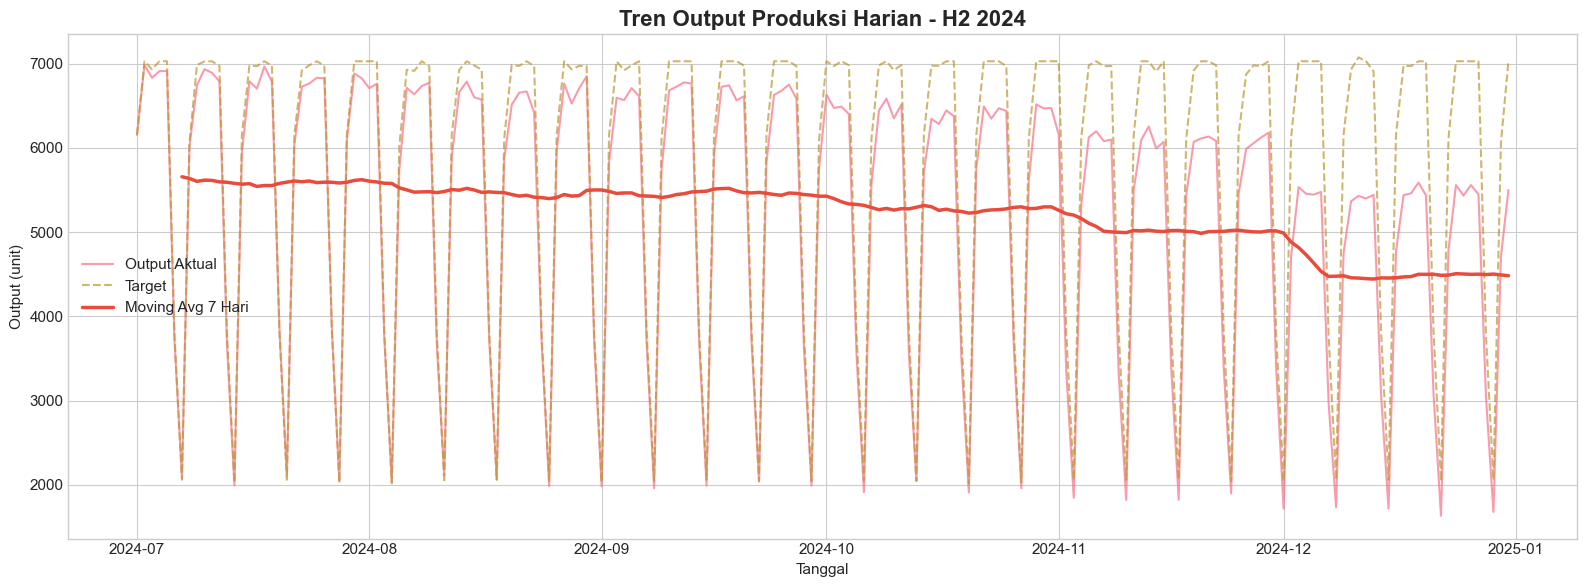

In [6]:
# Tren output harian
daily = df.groupby('production_date').agg(
    output=('output_qty', 'sum'),
    target=('target_qty', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily['production_date'], daily['output'], label='Output Aktual', linewidth=1.5, alpha=0.7)
ax.plot(daily['production_date'], daily['target'], label='Target', linewidth=1.5, alpha=0.7, linestyle='--')

# Rolling average 7 hari
ax.plot(daily['production_date'], daily['output'].rolling(7).mean(), label='Moving Avg 7 Hari',
        linewidth=2.5, color='#e74c3c')

ax.set_title('Tren Output Produksi Harian - H2 2024', fontsize=16, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Output (unit)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

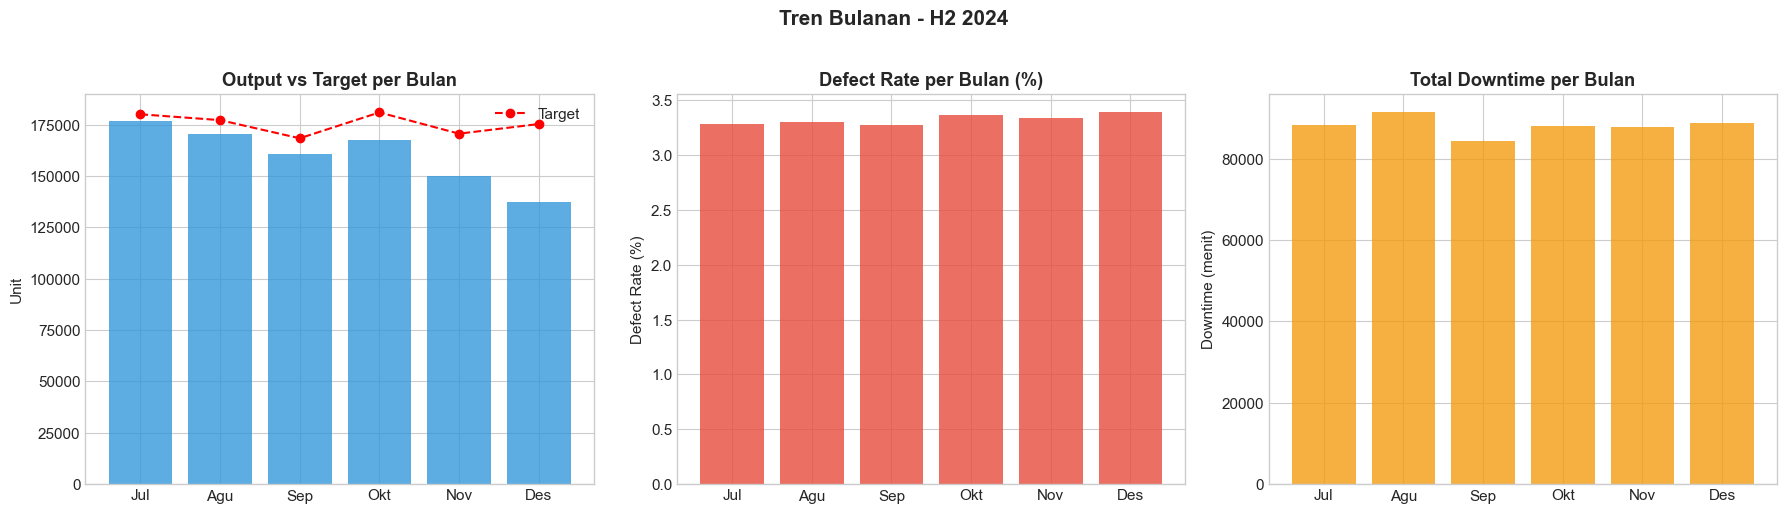

In [7]:
# Tren output bulanan
monthly = df.groupby('month').agg(
    output=('output_qty', 'sum'),
    target=('target_qty', 'sum'),
    defect=('defect_qty', 'sum'),
    downtime=('downtime_minutes', 'sum')
).reset_index()
monthly['achievement'] = monthly['output'] / monthly['target'] * 100
monthly['defect_rate'] = monthly['defect'] / monthly['output'] * 100
monthly['month_label'] = ['Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(monthly['month_label'], monthly['output'], color='#3498db', alpha=0.8)
axes[0].plot(monthly['month_label'], monthly['target'], 'r--o', label='Target')
axes[0].set_title('Output vs Target per Bulan', fontweight='bold')
axes[0].set_ylabel('Unit')
axes[0].legend()

axes[1].bar(monthly['month_label'], monthly['defect_rate'], color='#e74c3c', alpha=0.8)
axes[1].set_title('Defect Rate per Bulan (%)', fontweight='bold')
axes[1].set_ylabel('Defect Rate (%)')

axes[2].bar(monthly['month_label'], monthly['downtime'], color='#f39c12', alpha=0.8)
axes[2].set_title('Total Downtime per Bulan', fontweight='bold')
axes[2].set_ylabel('Downtime (menit)')

plt.suptitle('Tren Bulanan - H2 2024', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Perbandingan Line Produksi (Q2: Line mana paling produktif?)

In [8]:
# Output per line
line_perf = df.groupby('line_name').agg(
    total_output=('output_qty', 'sum'),
    total_target=('target_qty', 'sum'),
    total_defect=('defect_qty', 'sum'),
    avg_downtime=('downtime_minutes', 'mean'),
    count=('production_id', 'count')
).reset_index()
line_perf['achievement'] = (line_perf['total_output'] / line_perf['total_target'] * 100).round(1)
line_perf['defect_rate'] = (line_perf['total_defect'] / line_perf['total_output'] * 100).round(2)
line_perf['output_share'] = (line_perf['total_output'] / line_perf['total_output'].sum() * 100).round(1)

print('Performa per Line Produksi:')
display(line_perf.sort_values('total_output', ascending=False))

Performa per Line Produksi:


,line_name,total_output,total_target,total_defect,avg_downtime,count,achievement,defect_rate,output_share
0,Line A,203533,227866,8338,20.13,4947,89.30,4.10,21.20
2,Line C,201709,218199,7556,23.75,4939,92.40,3.75,21
1,Line B,192078,211026,4793,24.01,4935,91,2.50,20
3,Line D,184814,202350,4620,23.15,4948,91.30,2.50,19.20
4,Line E,179858,193187,6649,15.96,4949,93.10,3.70,18.70


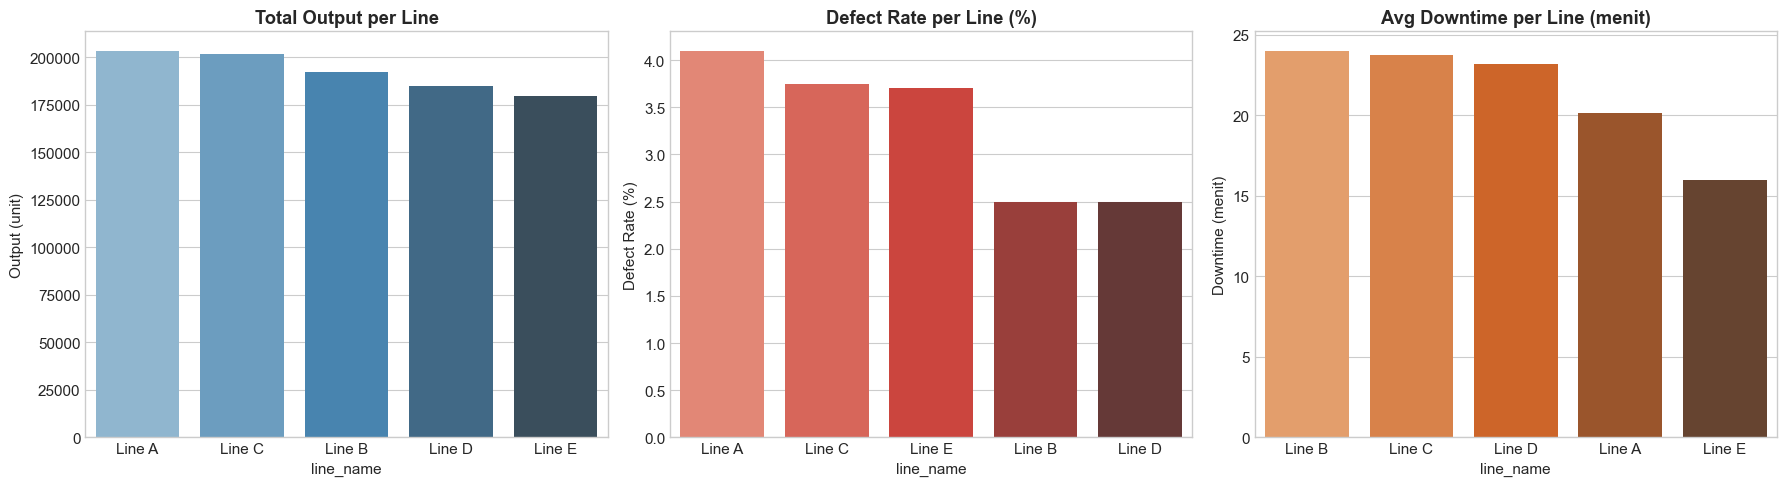

In [9]:
# Visualisasi perbandingan line
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=line_perf.sort_values('total_output', ascending=False), 
            x='line_name', y='total_output', ax=axes[0], palette='Blues_d')
axes[0].set_title('Total Output per Line', fontweight='bold')
axes[0].set_ylabel('Output (unit)')

sns.barplot(data=line_perf.sort_values('defect_rate', ascending=False),
            x='line_name', y='defect_rate', ax=axes[1], palette='Reds_d')
axes[1].set_title('Defect Rate per Line (%)', fontweight='bold')
axes[1].set_ylabel('Defect Rate (%)')

sns.barplot(data=line_perf.sort_values('avg_downtime', ascending=False),
            x='line_name', y='avg_downtime', ax=axes[2], palette='Oranges_d')
axes[2].set_title('Avg Downtime per Line (menit)', fontweight='bold')
axes[2].set_ylabel('Downtime (menit)')

plt.tight_layout()
plt.show()

---
## 5. Analisis Shift (Q3: Shift mana defect rate tertinggi?)

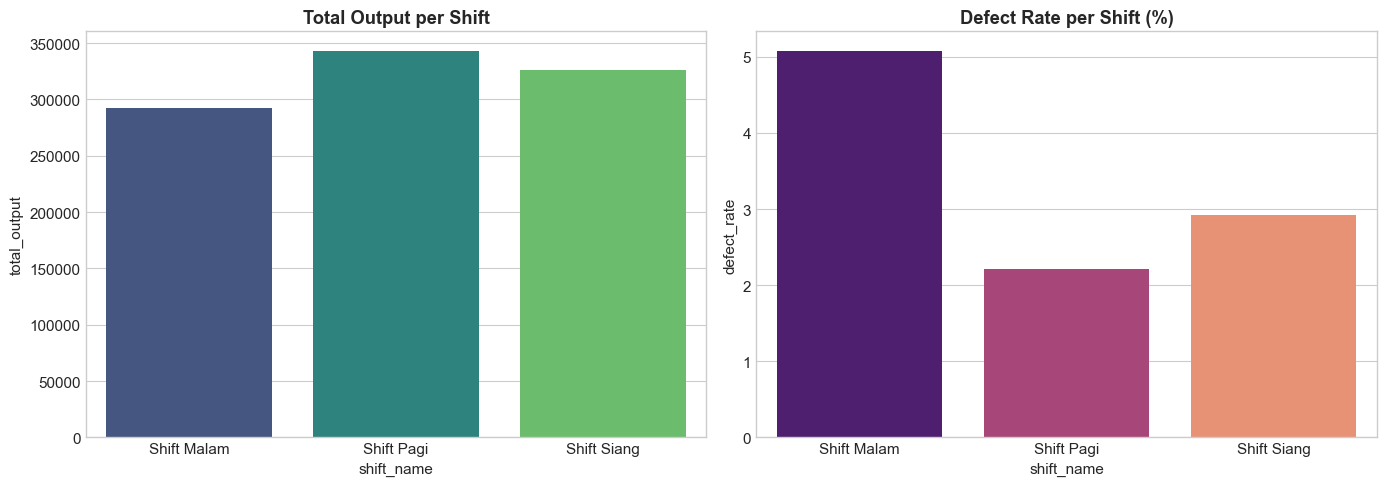

Performa per Shift:


,shift_name,total_output,total_defect,avg_downtime,defect_rate
0,Shift Malam,292525,14869,21.08,5.08
1,Shift Pagi,343224,7570,21.20,2.21
2,Shift Siang,326243,9517,21.91,2.92


In [10]:
# Performa per shift
shift_perf = df.groupby('shift_name').agg(
    total_output=('output_qty', 'sum'),
    total_defect=('defect_qty', 'sum'),
    avg_downtime=('downtime_minutes', 'mean')
).reset_index()
shift_perf['defect_rate'] = (shift_perf['total_defect'] / shift_perf['total_output'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=shift_perf, x='shift_name', y='total_output', ax=axes[0], palette='viridis')
axes[0].set_title('Total Output per Shift', fontweight='bold')

sns.barplot(data=shift_perf, x='shift_name', y='defect_rate', ax=axes[1], palette='magma')
axes[1].set_title('Defect Rate per Shift (%)', fontweight='bold')

plt.tight_layout()
plt.show()

print('Performa per Shift:')
display(shift_perf)

---
## 6. Analisis Mesin & Downtime (Q4: Mesin mana paling sering downtime?)

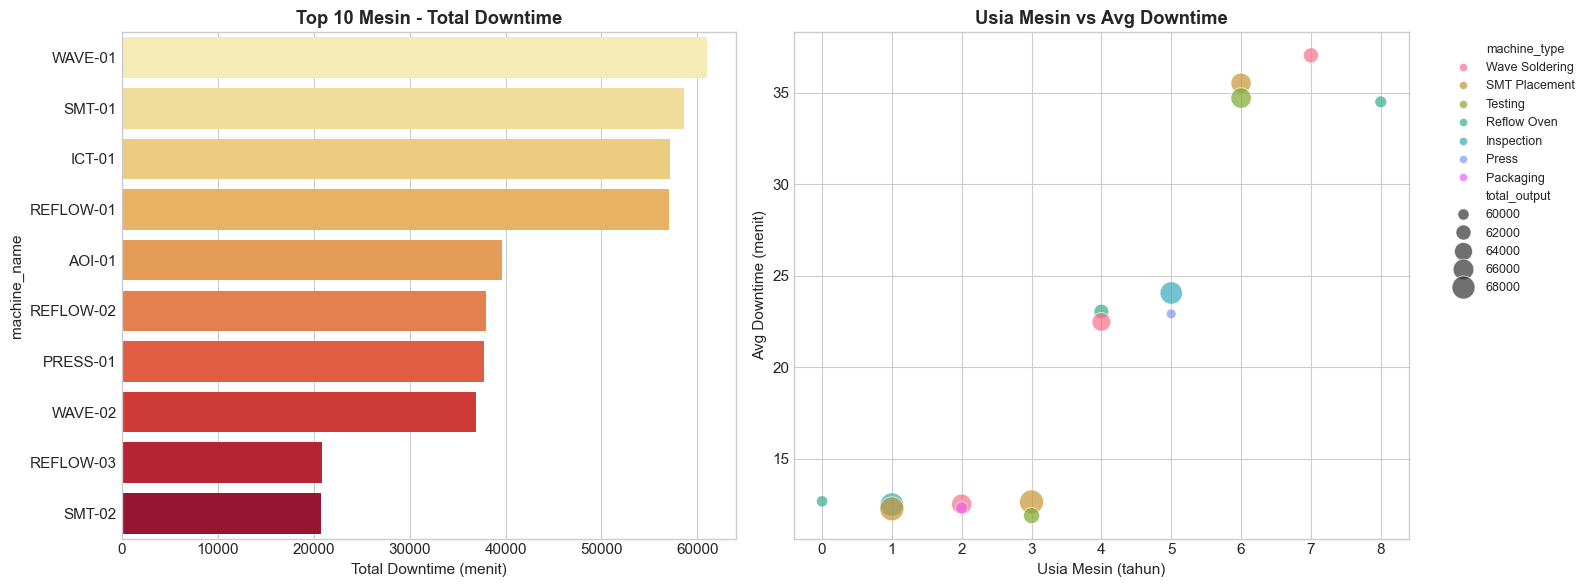

In [11]:
# Downtime per mesin
machine_perf = df.groupby(['machine_name', 'machine_type', 'purchase_year']).agg(
    total_downtime=('downtime_minutes', 'sum'),
    avg_downtime=('downtime_minutes', 'mean'),
    total_output=('output_qty', 'sum')
).reset_index()
machine_perf['machine_age'] = 2024 - machine_perf['purchase_year']
machine_perf = machine_perf.sort_values('total_downtime', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=machine_perf.head(10), y='machine_name', x='total_downtime', ax=axes[0], palette='YlOrRd')
axes[0].set_title('Top 10 Mesin - Total Downtime', fontweight='bold')
axes[0].set_xlabel('Total Downtime (menit)')

sns.scatterplot(data=machine_perf, x='machine_age', y='avg_downtime', size='total_output',
                hue='machine_type', ax=axes[1], sizes=(50, 300), alpha=0.7)
axes[1].set_title('Usia Mesin vs Avg Downtime', fontweight='bold')
axes[1].set_xlabel('Usia Mesin (tahun)')
axes[1].set_ylabel('Avg Downtime (menit)')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

---
## 7. Korelasi Downtime vs Output (Q5)

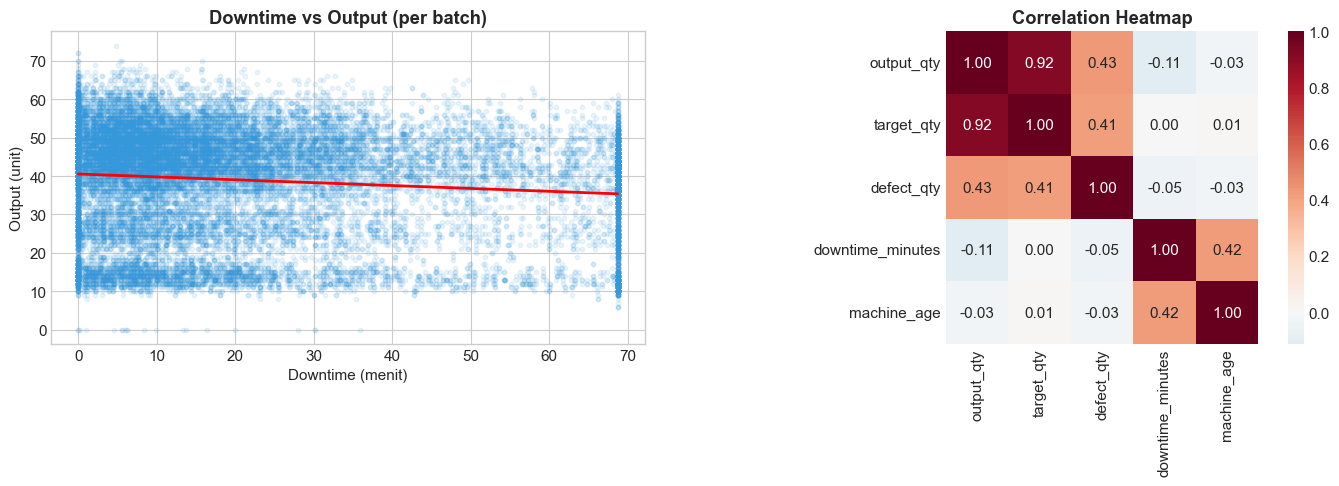

Korelasi Downtime vs Output: -0.113


In [12]:
# Scatter plot downtime vs output
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['downtime_minutes'], df['output_qty'], alpha=0.1, s=10, color='#3498db')
z = np.polyfit(df['downtime_minutes'], df['output_qty'], 1)
p = np.poly1d(z)
axes[0].plot(sorted(df['downtime_minutes']), p(sorted(df['downtime_minutes'])), 'r-', linewidth=2)
axes[0].set_title('Downtime vs Output (per batch)', fontweight='bold')
axes[0].set_xlabel('Downtime (menit)')
axes[0].set_ylabel('Output (unit)')

# Correlation heatmap
numeric_cols = ['output_qty', 'target_qty', 'defect_qty', 'downtime_minutes', 'machine_age']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=axes[1], square=True)
axes[1].set_title('Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Korelasi Downtime vs Output: {df["downtime_minutes"].corr(df["output_qty"]):.3f}')

---
## 8. Analisis Produk & Defect (Q6: Produk mana paling banyak defect?)

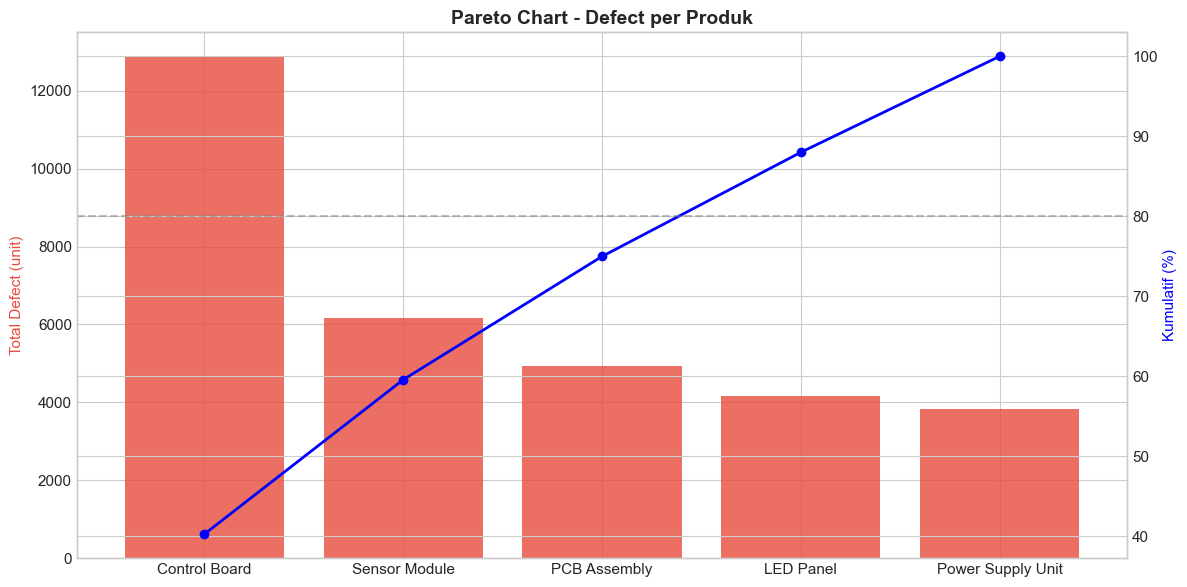

Defect Rate per Produk:


,product_name,total_output,total_defect,defect_rate
0,Control Board,194986,12858,6.59
4,Sensor Module,193856,6171,3.18
2,PCB Assembly,194510,4928,2.53
1,LED Panel,185397,4162,2.24
3,Power Supply Unit,193243,3837,1.99


In [13]:
# Defect per produk
product_perf = df.groupby('product_name').agg(
    total_output=('output_qty', 'sum'),
    total_defect=('defect_qty', 'sum')
).reset_index()
product_perf['defect_rate'] = (product_perf['total_defect'] / product_perf['total_output'] * 100).round(2)
product_perf = product_perf.sort_values('total_defect', ascending=False)

# Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 6))
product_perf_sorted = product_perf.sort_values('total_defect', ascending=False)
ax1.bar(product_perf_sorted['product_name'], product_perf_sorted['total_defect'], color='#e74c3c', alpha=0.8)
ax1.set_ylabel('Total Defect (unit)', color='#e74c3c')
ax1.set_title('Pareto Chart - Defect per Produk', fontsize=14, fontweight='bold')

ax2 = ax1.twinx()
cumulative = product_perf_sorted['total_defect'].cumsum() / product_perf_sorted['total_defect'].sum() * 100
ax2.plot(product_perf_sorted['product_name'], cumulative, 'b-o', linewidth=2)
ax2.set_ylabel('Kumulatif (%)', color='blue')
ax2.axhline(y=80, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print('Defect Rate per Produk:')
display(product_perf)

---
## 9. Pola Day-of-Week (Q7: Ada pola harian?)

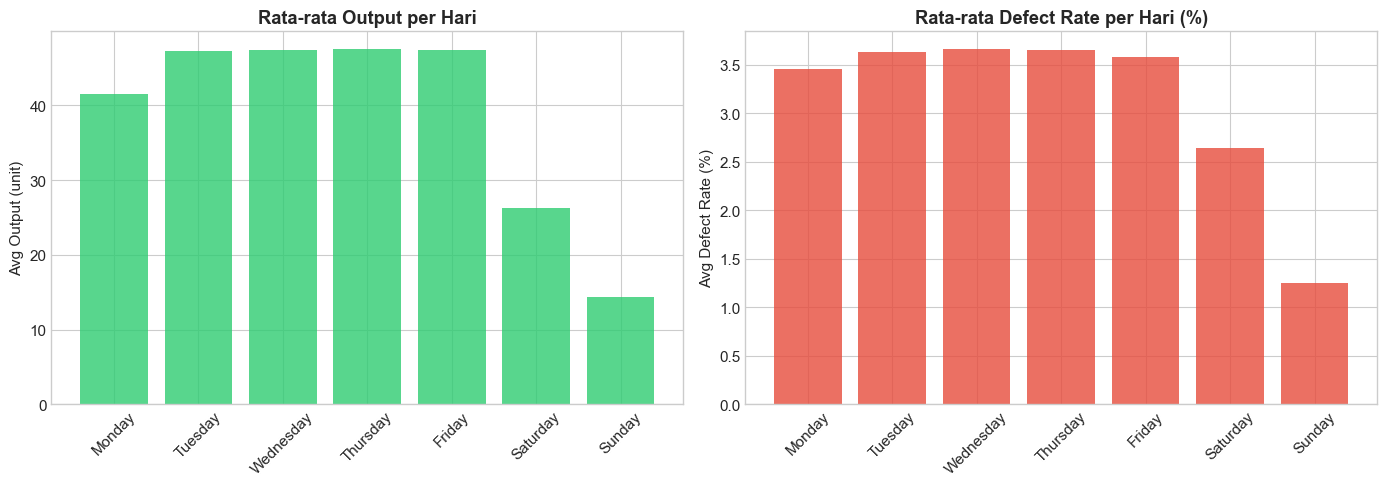

In [14]:
# Output per hari dalam seminggu
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_perf = df.groupby('day_name').agg(
    avg_output=('output_qty', 'mean'),
    avg_defect_rate=('defect_rate', 'mean')
).reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(day_perf.index, day_perf['avg_output'], color='#2ecc71', alpha=0.8)
axes[0].set_title('Rata-rata Output per Hari', fontweight='bold')
axes[0].set_ylabel('Avg Output (unit)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(day_perf.index, day_perf['avg_defect_rate'], color='#e74c3c', alpha=0.8)
axes[1].set_title('Rata-rata Defect Rate per Hari (%)', fontweight='bold')
axes[1].set_ylabel('Avg Defect Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 10. Distribusi Output per Shift per Line

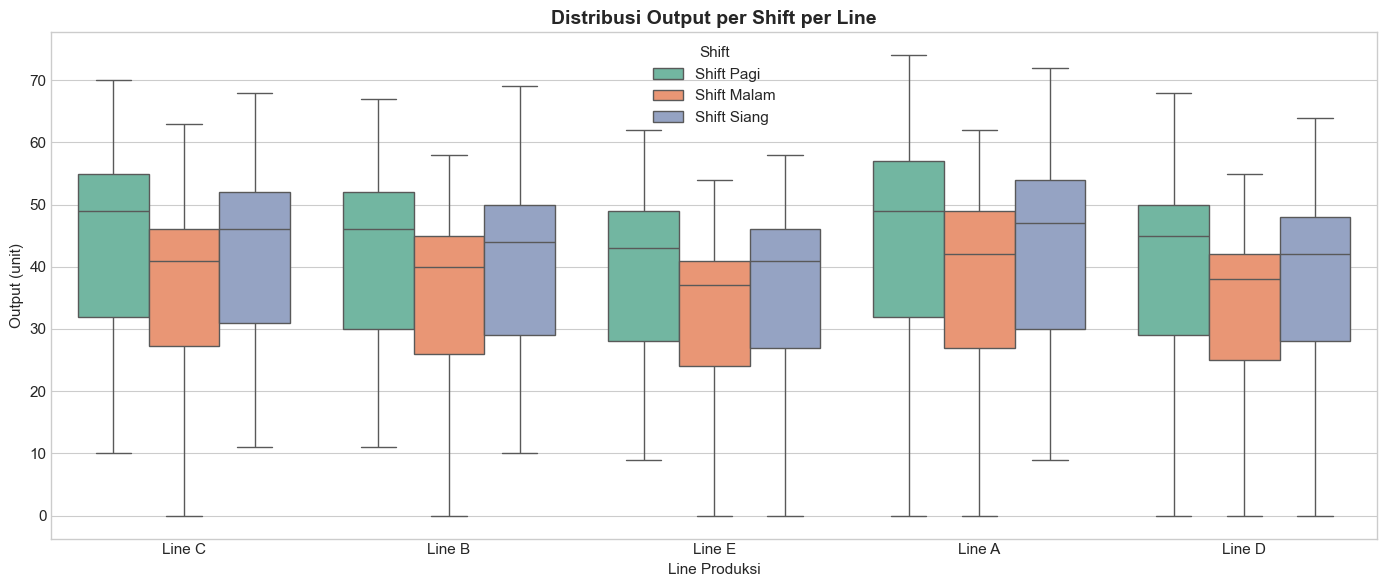

In [15]:
# Boxplot output per shift per line
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x='line_name', y='output_qty', hue='shift_name', ax=ax, palette='Set2')
ax.set_title('Distribusi Output per Shift per Line', fontsize=14, fontweight='bold')
ax.set_xlabel('Line Produksi')
ax.set_ylabel('Output (unit)')
ax.legend(title='Shift')
plt.tight_layout()
plt.show()

---
## 11. Pivot Table Analysis

In [16]:
# Pivot table: Output per Line per Bulan
pivot_output = df.pivot_table(values='output_qty', index='line_name', columns='month',
                              aggfunc='sum', margins=True, margins_name='Total')
pivot_output.columns = ['Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des', 'Total']
print('Output per Line per Bulan:')
display(pivot_output)

Output per Line per Bulan:


,Jul,Agu,Sep,Okt,Nov,Des,Total
line_name,,,,,,,
Line A,38359,36957,34762,36123,32588,24744,203533
Line B,34980,33898,31835,33043,29737,28585,192078
Line C,36731,35340,33468,35183,30933,30054,201709
Line D,33847,32473,30576,31856,28708,27354,184814
Line E,32797,31576,29864,31120,27838,26663,179858
Total,176714,170244,160505,167325,149804,137400,961992


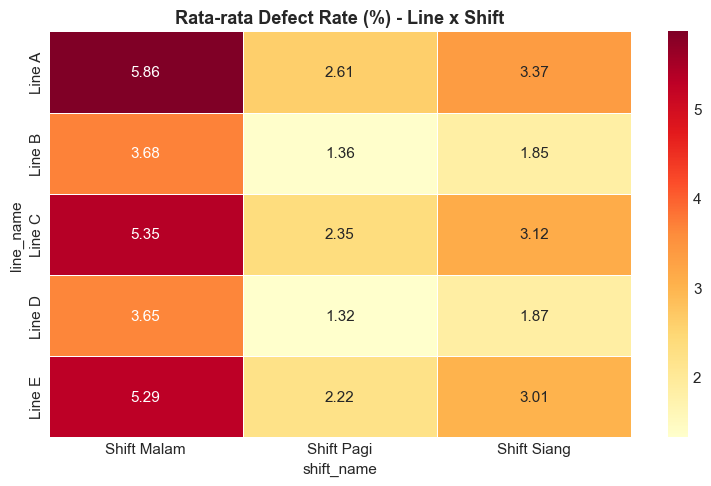

In [17]:
# Heatmap defect rate: Line x Shift
pivot_defect = df.pivot_table(values='defect_rate', index='line_name', columns='shift_name', aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_defect, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Rata-rata Defect Rate (%) - Line x Shift', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 12. Ringkasan Temuan Kunci

### Temuan Utama:
1. **Tren Menurun**: Output produksi menunjukkan tren penurunan dari Juli ke Desember
2. **Shift Malam**: Shift Malam memiliki defect rate paling tinggi dibanding shift lainnya
3. **Mesin Tua**: Mesin dengan usia >5 tahun menunjukkan downtime yang lebih tinggi
4. **Control Board**: Produk Control Board memiliki defect rate tertinggi
5. **Korelasi Negatif**: Terdapat korelasi negatif antara downtime dan output
6. **Senin Effect**: Output hari Senin cenderung lebih rendah (start-up effect)
7. **Weekend**: Output di hari Sabtu dan Minggu jauh lebih rendah

Temuan ini akan dielaborasi lebih lanjut di dokumen Insights & Recommendations.